# Q learning : application

Dans cette séance on testera l'algorithme de Q learning avec un environnement de simulation d'OpenAI gymnasium (anciennement gym)

https://gymnasium.farama.org/

### Quelques installations

Selon ce qui est déjà installé dans votre environnement de travail, vous aurez besoin de quelques librairies.

In [2]:
%pip -q install --upgrade pip
%pip -q install ipywidgets numpy ffmpeg ffmpeg-python swig

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip -q install ufal.pybox2d
#%pip -q install gym[box2d]
%pip -q install gymnasium

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo

import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.animation as animation
import matplotlib.cm as cm

In [5]:
# pour lire des videos locales facilement
from base64 import b64encode
from IPython.display import HTML


def play_video(v_path,width=200):
      mp4 = open(v_path,'rb').read()
      data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
      return HTML("""
          <video width=%d controls>
          <source src="%s" type="video/mp4">
          </video>
          """ % (width,data_url))

## Découverte des environnements d'OpenAI Gym

Gym définit des mondes dans lesquels on peut avoir un agent qui agit sur l'environnement, et avoir l'observation de certaines variables de cet environnement.

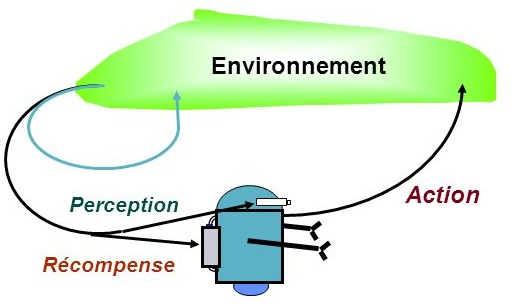




On utilisera plusieurs environnements, mais voyons déjà celui ci:
un module lunaire essaie d'atterrir en douceur sur un emplacement fixé

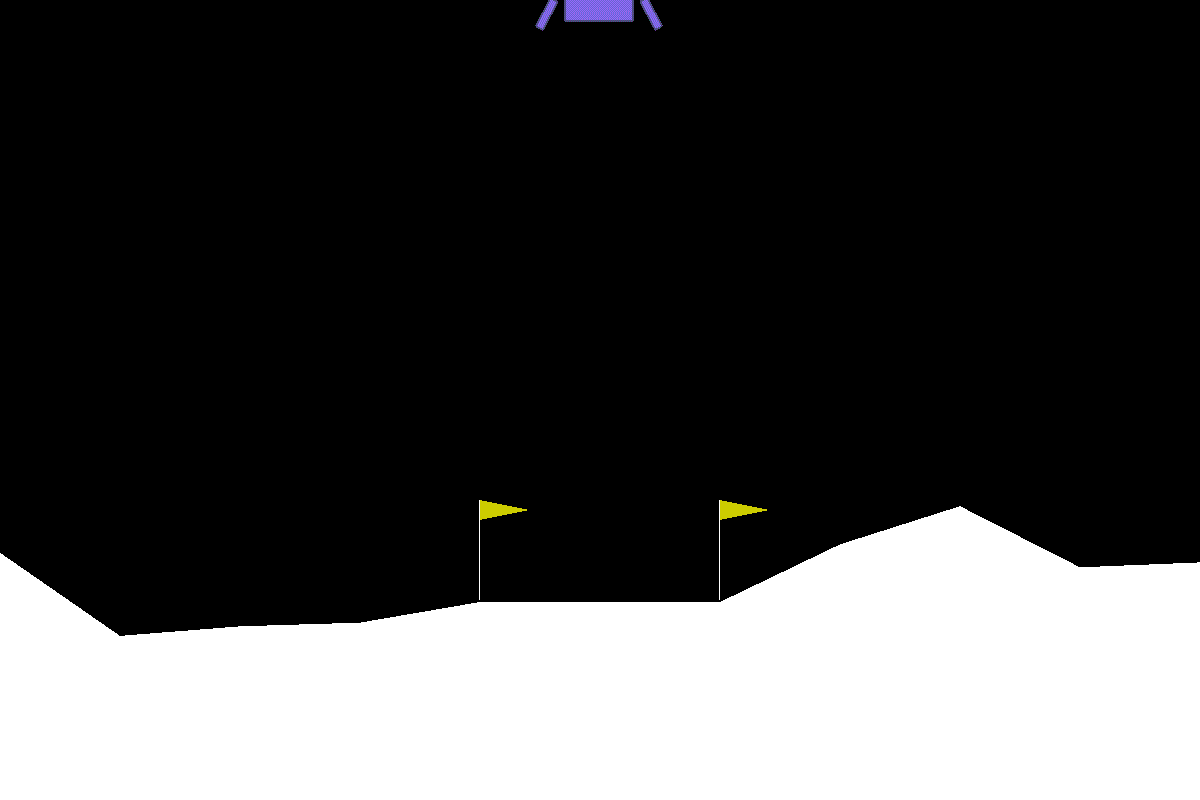

In [6]:
%pip -q install Box2D pygame

Note: you may need to restart the kernel to use updated packages.


 - On charge un environnement. `l'option render_mode` détermine le rendu visuel des simulations.
 - ici on sauvera des images
 - on a l'initialise sur un état de départ. 
    - -> renvoie une "observation" : un état de l'environnement

In [7]:
# Environment creation with render mode specified upfront
env = gym.make("LunarLander-v3",continuous=False, gravity=-10.0,enable_wind=False, wind_power=15.0, turbulence_power=1.5)
# on l'initialise sur un état de départ. -> renvoie une "observation" : un état de l'environnement
print("on l'initialise sur un état de départ", env.reset())

# on peut échantilloner une action au hasard
print( "action sampled :" ,env.action_space.sample())

on l'initialise sur un état de départ (array([-3.8480759e-04,  1.4036937e+00, -3.8987558e-02, -3.2117522e-01,
        4.5263232e-04,  8.8312607e-03,  0.0000000e+00,  0.0000000e+00],
      dtype=float32), {})
action sampled : 3


__Le LunarLander-v3 possède un espace d'états continu (8 variables) et un espace d'actions discret (4 actions).__.        
__Pour chaque environnement comprend, les actions disponibles.__

In [8]:
# Espace des actions : Nop, fire left engine, main engine, right engine
print("Espace des actions : Nop, fire left engine, main engine, right engine : " ,env.action_space)

Espace des actions : Nop, fire left engine, main engine, right engine :  Discrete(4)


__`Action 0 : Ne rien faire (do nothing)`__.  

__Aucun moteur n'est allumé__, 
- Le lander est soumis uniquement à la gravité et à l'inertie
- Utile pour économiser du carburant
- Le carburant soit infini dans cet environnement

__`Action 1 : Moteur d'orientation gauche (fire left orientation engine)`__

__Allume le propulseur latéral gauche__, 
- Fait pivoter le lander vers la droite (rotation horaire)
- Coût : -0.03 points par frame​
- Utilisé pour corriger l'angle lorsque le lander penche trop à gauche

__`Action 2 : Moteur principal (fire main engine)`__

__Allume le propulseur principal (orienté vers le bas)__
- Pousse le lander vers le haut, ralentissant la descente
- Coût : -0.3 points par frame​
- Le plus coûteux mais essentiel pour contrôler l'altitude et éviter un crash

__`Action 3 : Moteur d'orientation droit (fire right orientation engine)`__

__Allume le propulseur latéral droit__
- Fait pivoter le lander vers la gauche (rotation anti-horaire)
- Coût : -0.03 points par frame​
- Utilisé pour corriger l'angle lorsque le lander penche trop à droite

__`L'environnement définit un certain nombre de variables observables`__.

- observation[0] Position X (horizontal) - `cible à 0.0`. 
- observation[1] Position Y (hauteur) - `plus haut = mieux`.  
- observation[2] Vitesse Vx (horizontale) - `doit être proche de 0 à l'atterrissage`. 
- observation[3] Vitesse Vy (verticale) - `doit être faible (descente douce)`.  
- observation[4] Angle theta (en radians) - `doit être proche de 0 (vertical)`. 
- observation[5] Vitesse angulaire theta_dot - `doit être proche de 0`.  
- observation[6] Contact jambe gauche `(0 ou 1)`. 
- observation[7] Contact jambe droite `(0 ou 1)`.  


__`A chaque action faite par un agent :`__ 

- l'environnement informe sur le nouvel état, 
- donne une récompense (prédéfinie et fixé pour chaque monde), 
- renvoie aussi une condition qui précise si la simulation est finie (crash ou atterrissage réussi).

In [9]:
#faire une action, constater l'état suivant, reward etc
for i in range(4): 
    observation, reward, done, truncated, info = env.step(i)
    print(f'X : {observation[0]:.4f} Y : {observation[1]:.4f} Vx : {observation[2]:.4f} Vy : {observation[3]:.4f} theta : {observation[4]:.4f} theta_dot : {observation[5]:.4f} - JG : : {observation[6]:.4f}, JD : {observation[7]:.4f}')   

X : -0.0008 Y : 1.3959 Vx : -0.0389 Vy : -0.3468 theta : 0.0009 theta_dot : 0.0087 - JG : : 0.0000, JD : 0.0000
X : -0.0012 Y : 1.3875 Vx : -0.0464 Vy : -0.3739 theta : 0.0028 theta_dot : 0.0385 - JG : : 0.0000, JD : 0.0000
X : -0.0017 Y : 1.3796 Vx : -0.0465 Vy : -0.3494 theta : 0.0047 theta_dot : 0.0386 - JG : : 0.0000, JD : 0.0000
X : -0.0020 Y : 1.3712 Vx : -0.0379 Vy : -0.3757 theta : 0.0049 theta_dot : 0.0041 - JG : : 0.0000, JD : 0.0000


In [10]:
%pip -q install moviepy

Note: you may need to restart the kernel to use updated packages.


## I) Ecrire une fonction de simulation qui fait une séquence d'action au hasard

et enregistre les récompenses et la trajectoire de chaque variable observée.


$\Large Q(s,a)←Q(s,a) + \alpha *[r + \gamma * max_{a^′} Q(s^′,a^′)− Q(s,a)]$

Boucle classique :

1 - Initialiser Q-table (ou NN).  
2 - Pour chaque épisode, loop:   
 - choisir $\epsilon$-greedy action.   
 - appliquer, observer $s^’$, reward, done.   
 - mettre à jour Q

In [11]:
# version à compléter
def random_sequence(env, buffer_length):
        trajectory= []
        observation, _ = env.reset(seed=42)
        # sauve les observations pour faire des stats
        trajectory.append(observation)
        # somme des renforcements
        reward = 0    
        print(f'etape - 0  reward : {reward:.4f} - (X: {observation[0]:.4f}, Y: {observation[1]:.4f}) - (Vx: {observation[2]:.4f}, Vy: {observation[3]:.4f}) - (theta : {observation[4]:.4f}, theta_dot: {observation[5]:.4f}) JG : {observation[6]:.4f} - JD : {observation[7]:.4f}')   
        t=0
        done = False
        while not done:
            action = env.action_space.sample()
            observation, reward, terminated, truncated, info = env.step(action)
            print(f'etape - {action} reward : {reward:.4f} - (X: {observation[0]:.4f}, Y: {observation[1]:.4f}) - (Vx: {observation[2]:.4f}, Vy: {observation[3]:.4f}) - (theta: {observation[4]:.4f}, theta_dot: {observation[5]:.4f}) JG: {observation[6]:.4f} - JD: {observation[7]:.4f}')   
        
            trajectory.append(observation)
            reward += reward
            t+=1
            if t >= buffer_length:
                break
            done = terminated or truncated
        env.close()
        return reward, trajectory

In [12]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# voilà comment créer l'environnement pour avoir accès à une simulation d'épisode et les stats d'un épisode
# un nouvel épisode est créé à chaque env.reset(), et stocké.
_PATH_="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP3/lunar-lander/"
_FILE_=_PATH_+ "eval-episode-0.mp4"

env = gym.make("LunarLander-v3",continuous=False, gravity=-11,
               enable_wind=False, wind_power=0, turbulence_power=0,
               render_mode="rgb_array")

# Supprimer les anciennes vidéos
for video_file in glob.glob(f"{_FILE_}"):
    os.remove(video_file)

env = RecordVideo(env, video_folder=_PATH_, name_prefix="eval", episode_trigger=lambda x: True)
buffer_length=200
env = RecordEpisodeStatistics(env, buffer_length=buffer_length)
total, trajectory = random_sequence(env,buffer_length)
print("total reward = ", total)
print(f'Episode time taken: {env.time_queue}')
print(f'Episode total rewards: {env.return_queue}')
print(f'Episode lengths: {env.length_queue}')
# une video a du être créée pour chaque épisode (ici un seul)
PATH="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP3/lunar-lander/eval-episode-0.mp4"
play_video(PATH,width=600)

etape - 0  reward : 0.0000 - (X: 0.0023, Y: 1.4181) - (Vx: 0.2326, Vy: 0.3178) - (theta : -0.0027, theta_dot: -0.0527) JG : 0.0000 - JD : 0.0000
etape - 3 reward : 0.6834 - (X: 0.0047, Y: 1.4246) - (Vx: 0.2400, Vy: 0.2895) - (theta: -0.0068, theta_dot: -0.0830) JG: 0.0000 - JD: 0.0000
etape - 3 reward : 0.2191 - (X: 0.0071, Y: 1.4304) - (Vx: 0.2506, Vy: 0.2605) - (theta: -0.0131, theta_dot: -0.1251) JG: 0.0000 - JD: 0.0000
etape - 0 reward : 0.9054 - (X: 0.0095, Y: 1.4356) - (Vx: 0.2506, Vy: 0.2311) - (theta: -0.0193, theta_dot: -0.1251) JG: 0.0000 - JD: 0.0000
etape - 3 reward : -0.3841 - (X: 0.0121, Y: 1.4402) - (Vx: 0.2624, Vy: 0.2022) - (theta: -0.0279, theta_dot: -0.1724) JG: 0.0000 - JD: 0.0000
etape - 2 reward : -3.0786 - (X: 0.0145, Y: 1.4454) - (Vx: 0.2543, Vy: 0.2326) - (theta: -0.0371, theta_dot: -0.1830) JG: 0.0000 - JD: 0.0000
etape - 1 reward : 1.6648 - (X: 0.0169, Y: 1.4500) - (Vx: 0.2422, Vy: 0.2035) - (theta: -0.0438, theta_dot: -0.1344) JG: 0.0000 - JD: 0.0000
etape -

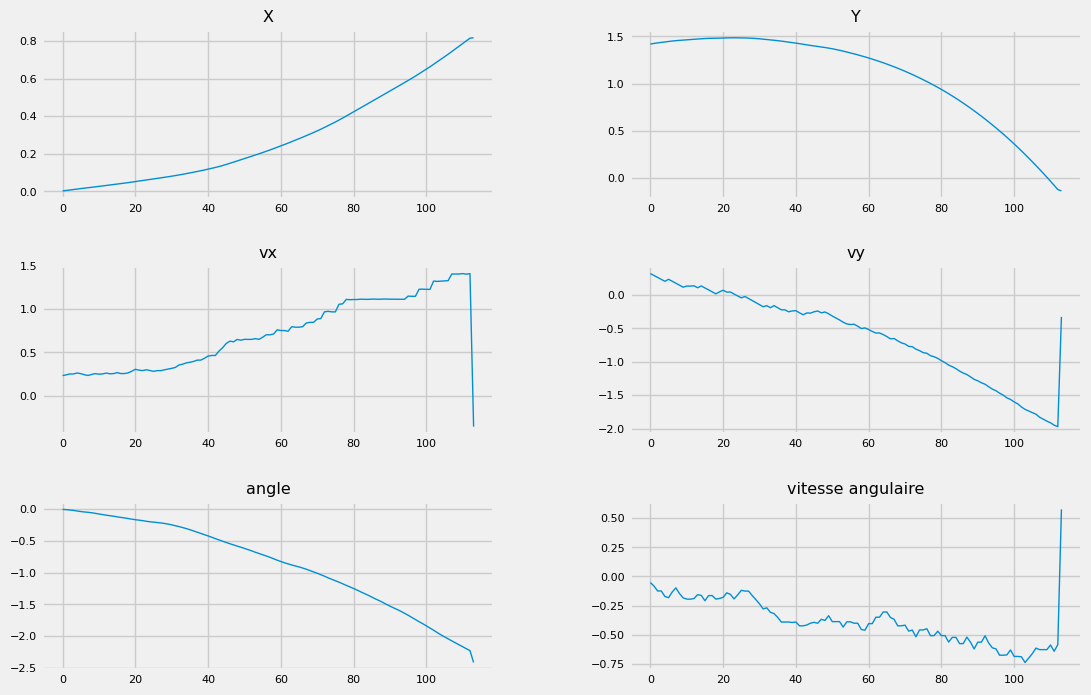

In [33]:
import numpy as np
# Convertir la liste trajectory en array NumPy
trajectory = np.array(trajectory)

# On peut observer l'évolution des variables au cours de la simulation
# Espace des observations
variables = {0:"X",1:"Y",   # Position X, Y
             2:"vx",3:"vy", # vecteur vitesse vx, vx
             4:"angle",     # / vertical
             5:"vitesse angulaire",
            }
%matplotlib inline
fig, axs = plt.subplots(3,2)
plt.style.use('fivethirtyeight')
plt.rcParams["figure.figsize"] = [13,8]
plt.rcParams['font.size'] = 8
plt.rcParams["figure.autolayout"] = True
fig.tight_layout()
fig.figsize = (20,20)
for i in range(6):
    axs[i//2,i%2].set_title(variables[i])
    axs[i//2,i%2].plot(trajectory[:,i],linewidth=1) 
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.3, hspace=0.4)      
plt.show()    


## Q learning dans l'environnement Frozen Lake

Nous allons d'abord expérimenter le Q-learning dans un environnement un peu plus simple avec peu d'états: le "frozen lake" où nous allons apprendre à un agent à rejoindre son but en évitant de tomber dans l'eau :

In [14]:
%pip -q install --upgrade stable-baselines3
%pip -q install --upgrade gymnasium

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


<div><img src="frozen_lake.gif" width="200"></div>

N'hésitez pas à aller voir la doc:

https://gymnasium.farama.org/environments/toy_text/frozen_lake/

Dans une 2e partie nous  verrons aussi que l'environnement peut être traité avec des actions non-déterministes (sur la glace on ne contrôle pas toujours ses mouvements !)

on peut customiser aussi en utilisant les codes :

S=start, G=goal, H=hole, F=frozen

In [39]:
#desc4=["SFFF","HHFH","FFFF","GFFF"]
desc8=["SFFFFFFF","FFFFFFFF","FFFHFFFF","FFFFFHFF","FFFHFFFF","FHHFFFHF","FHFFHFHF","FFFHFFFG"]
desc4=["SFFF","FHFH","FFFH","HFFG"]
# Transitions non déterministes
env = gym.make('FrozenLake-v1', desc=desc4, is_slippery=False,render_mode="rgb_array")
# Transitions non déterministes
# env = gym.make('FrozenLake-v1',desc=desc4,is_slippery=True,success_rate=1.0/3.0,reward_schedule=(1, 0, 0),render_mode="rgb_array")
env.reset()
# si aucune description ou map_name n'est donné un environnement est généré au hasard
# en forçant l'existence d'un chemin


(0, {'prob': 1})

on peut observer un environnement en l'affichant.

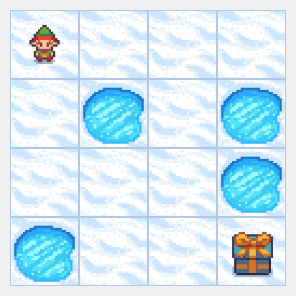

In [40]:
def image_render():
    image = env.render()
    plt.figure(figsize=(3, 3))
    plt.imshow(image) # type: ignore
    plt.axis('off') 
    plt.show()

image_render()    

### Explorer l'environnement

Vérifiez le nombre d'actions, essayer de trouver quel code correspond à quelle action en observant le résultat d'une action sur un environnement donné. 
 - L'espace d'action (Action Space) pour Frozen Lake est Discrete(4), ce qui signifie qu'il y a 4 actions possibles

In [41]:
print(f"L'espace d'action (Action Space) pour Frozen Lake : {env.action_space.n}")

action_name = {0:"GAUCHE",
               1:"BAS",
               2:"DROITE",
               3:"HAUT"
              }

#faire une action, constater l'état suivant, reward etc
for i in range(1,4): 
    observation, reward, done, truncated, info = env.step(i)
    print(f'Action : {action_name[i]} - Etat : {observation} - Reward : {reward} - Done : {done}')   
#image_render()
    


L'espace d'action (Action Space) pour Frozen Lake : 4
Action : BAS - Etat : 4 - Reward : 0 - Done : False
Action : DROITE - Etat : 5 - Reward : 0 - Done : True
Action : HAUT - Etat : 5 - Reward : 0 - Done : True


`Regarder ce qui définit un état donné`

L'environnement se présente sous forme d'un grid world (grille) de dimension 4×4 par défaut, qui donne 16 états possibles.    
Chaque case de la grille correspond à un état distinct dans lequel l'agent peut se trouver. 

Les états sont généralement numérotés de 0 à 15 pour la grille 4×4 :​
- L'état 0 correspond à la position de départ (case en haut à gauche, position )
- L'état 15 correspond à la position d'arrivée (case en bas à droite, position )​
- Les autres états représentent les cases intermédiaires, certaines étant gelée (F), d'autres des trous (H)

In [18]:
print("Espace des actions : ", env.action_space)
print("Espace des observations : ", env.observation_space)  

Espace des actions :  Discrete(4)
Espace des observations :  Discrete(16)


`Essayer de trouver les récompenses`.   

- reward schedule par défaut reward_schedule=(1, 0, 0)
  - Reach goal: +1
  - Reach hole: 0
  - Reach frozen: 0

In [42]:
def display_table_with_action_names(P, action_name):
    for state, actions in P.items():
        print(f"État {state}:")
        for action, transitions in actions.items():
            action_desc = action_name.get(action, f"Action {action}")
            print(f"  Action '{action_desc}':")
            for prob, next_state, reward, done in transitions:
                terminal_status = "Terminal" if done else "Non-terminal"
                print(f"    -> Probabilité: {prob:.2f}, État suivant: {next_state}, Récompense: {reward}, terminal_status : {terminal_status}")
        break

__`La variable P représente la fonction de transition de probabilités de l’environnement de type Markov Decision Process (MDP)`.__

In [43]:
P = env.env.env.env.P # type: ignore
display_table_with_action_names(P, action_name)

État 0:
  Action 'GAUCHE':
    -> Probabilité: 1.00, État suivant: 0, Récompense: 0, terminal_status : Non-terminal
  Action 'BAS':
    -> Probabilité: 1.00, État suivant: 4, Récompense: 0, terminal_status : Non-terminal
  Action 'DROITE':
    -> Probabilité: 1.00, État suivant: 1, Récompense: 0, terminal_status : Non-terminal
  Action 'HAUT':
    -> Probabilité: 1.00, État suivant: 0, Récompense: 0, terminal_status : Non-terminal


In [44]:
%pip -q install tqdm

Note: you may need to restart the kernel to use updated packages.


###  Q-learning      
Nous allons maintenant implémenter un apprentissage par Q-learning :
:::


### __En définissant une table Q avec numpy, quelles sont les options pour initialiser cette table?__
   
`Initialiser la table Q avec des valeurs nulles permet de commencer son apprentissage sans biais initial`
- Q_table = np.zeros((state_space, action_space))
       
`Initialisater la table Q avec de petites valeurs aléatoire,permet d'encourager l'exploration initiale` :  
- Q_table = np.random.uniform(low=0, high=0.01, size=(state_space, action_space))
    
`Initialisation optimiste basée sur l'application d'un facteur multiplicateur aux valeurs de la table`
  - Q_table = np.ones((state_space, action_space)) * optimistic_value
        
`Initialisation la table Q basée sur des connaissances préalables`
  - Q_table = np.array([...]) 
        
:::

In [45]:
def init_Qtable(nb_states,nb_actions,opts=True):
    if  opts : Q_table = np.zeros((nb_states,nb_actions)) 
    else : Q_table = np.random.uniform(low=0, high=0.01, size=(nb_states, nb_actions))
    return Q_table

`Principe d'optimalité de Bellman` .   

:::

Ce principe stipule que la valeur optimale d'un état dépend de la récompense immédiate et de la valeur optimale de l'état suivant 

$\large R(π,s) = r (s,π(s)) + γR(π,δ(s,π(s))$

:::

:::
  - $r(s,π(s))$ : représente la récompense immédiate obtenue en prenant l'action $π(s)$ dans l'état s.
  - $δ(s,π(s))$ : représente l'état suivant après avoir appliqué l'action $π(s)$ dans l'état s.
  - $γR(π,δ(s,π(s)))$ : représente la récompense future attendue, actualisée par le facteur d'actualisation $γ$.

:::

`Apprentissage ε-greedy`
:::

La stratégie epsilon-greedy est utilisée dans l'apprentissage par renforcement pour équilibrer l'exploration et l'exploitation. 

__Principe de base de la stratégie epsilon-greedy fonctionne avec__ :

`Epsilon-decreasing :`   
  - Avec cette stratégie, la valeur de epsilon diminue progressivement au fur et à mesure que l'expérience progresse, favorisant une exploration plus importante au début et une exploitation accrue vers la fin.

`Epsilon-first :`   
 - Cette approche divise l'expérience en deux phases distinctes :
 
   - Une phase d'exploration pure (epsilon = 1) pendant εN essais 
   - Suivie d'une phase d'exploitation pure (epsilon = 0) pendant $(1-ε)$ N essais où N est le nombre total d'essais. 

Espilon-first sort du champ du TP il ne sera pas mis en oeuvre. 
:::

:::

 - `Q` est la table des valeurs Q (qualité) pour chaque paire état-action
    - `state` est l'état actuel
    - `epsilon` est la probabilité d'exploration

:::

In [23]:
def epsilon_greedy(Q, state, epsilon):
    rng = np.random.default_rng()
    random_value = rng.uniform(0, 1)
    explore = False
    if    random_value < epsilon: 
          explore = True
          return explore, env.action_space.sample()  # Exploration
    else:  
          explore = False
          return explore, np.argmax(Q[state])  # Exploitation

In [24]:
def display_behavior(all_bhavior):
    exploration_counts = np.cumsum(all_bhavior)
    exploitation_counts = np.arange(1, len(all_bhavior) + 1) - exploration_counts
    # Tracer les courbes
    fig, axs = plt.subplots()
    plt.style.use('fivethirtyeight')
    plt.rcParams["figure.figsize"] = [4,2]
    plt.rcParams['font.size'] = 6
    plt.rcParams["figure.autolayout"] = True
    fig.tight_layout()
    axs.set_title("Évolution des explorations versus exploitations")
    
    plt.plot(exploration_counts, label="Exploration", color="blue",linewidth=1)
    plt.plot(exploitation_counts, label="Exploitation", color="orange",linewidth=1)
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.3, hspace=0.4)  
    plt.xlabel("Épisodes")
    plt.ylabel("Nombre cumulatif")
    plt.legend()
    plt.grid(True)
    plt.show()

#### Tester 

 - Utiliser un entrainement assez rapide pour voir que cela semble fonctionner
 - Tester l'apprentissage avec la grille 4x4 "facile" puis la version "dure".
 - Afficher la courbe d'évolution de la récompense totale d'un épisode, 
 - Afficher la politique optimale définie par votre table finale (= affichez la meilleure action pour chaque état)
 - changez les valeurs des rewards pour accélérer l'entrainement

 Voici un schéma de boucle d'entrainement, qui doit dépendre d'un certain nombre de paramètres.

`Mise à jour de la table Q:`

La mise à jour de la valeur Q dans le cas où l'épisode est basée sur l'état suivant (next_state). 

$\large Q(s,a)=(1−α)⋅Q(s,a)+α⋅(r+γ.max_{a^′} Q(s^′,a^′)) $ .   

 - où $s^′$ représente le next_state

In [25]:
from tqdm import tqdm

def train(n_episodes, env, max_steps, Qtable, gamma=0.95, alpha=0.01, decay_rate = 0.99999995):
    all_rewards = []
    all_bhavior = []

    epsilon = 1
    min_epsilon = 0.01
  
    for episode in tqdm(range(2,n_episodes)):
        epsilon = max(min_epsilon, epsilon * (decay_rate ** episode))
        #epsilon = max_epsilon - (episode / n_episodes) * (max_epsilon - min_epsilon)
        #epsilon =  max(min_epsilon, epsilon)
        state, _ = env.reset()
        total_reward = 0
        for step in range(max_steps):
            # Choisir une action avec la stratégie epsilon-greedy
            explore, action = epsilon_greedy(Qtable, state, epsilon) 
            all_bhavior.append(explore)
            # Faire l'action et récupérer le résultat
            next_state, reward, done, truncated, _ = env.step(action)
            total_reward += reward
            # Mise à jour de Q(s,a)
            if not done and not truncated:
                Qtable[state, action] = (1 - alpha) * Qtable[state, action] + alpha * (reward + gamma * np.max(Qtable[next_state,:]))
            elif done:
                Qtable[state, action] = Qtable[state, action] + alpha * (reward - Qtable[state, action])
            if  done or truncated :  
                break
            state = next_state       
        all_rewards.append(total_reward)
    display_behavior(all_bhavior)     
    return Qtable, all_rewards

In [26]:
%matplotlib inline
def display_graph(all_rewards):
    fig, axs = plt.subplots()
    plt.style.use('fivethirtyeight')
    plt.rcParams["figure.figsize"] = [4,2]
    plt.rcParams['font.size'] = 6
    plt.rcParams["figure.autolayout"] = True
    fig.tight_layout()
    axs.set_title("All rewards")
    plt.plot(all_rewards,linewidth=1) 
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.3, hspace=0.4)      
    plt.show() 

In [27]:
def print_policy(policy, desc):
    print(f"Description : {desc} {len(desc)}")
   # print(f"Politique optimale : {policy}")

    arrows = ["\u2190", "\u2193", "\u2192", "\u2191"]  # Left, Down, Right, Up
    rows = len(desc)
    cols = [len(t) for t in desc]

    policy_desc = []
    for row in range(rows):
        policy_row = ""
        for col in range(cols[0]):
            if desc[row][col] == "H":
                policy_row += "H"
            elif desc[row][col] == "G":
                policy_row += "G"    
            else:
                action = policy[row * 4 + col]
                policy_row += arrows[action]
        policy_desc.append(policy_row)
    print("La policy optimale")    
    for row in policy_desc:
        print(row)

In [28]:
def change_rewards(P, move_penalty=-1, hole_penalty=-3, goal_reward=5,flag=True):    
    for _, actions in P.items():
        for _, transitions in actions.items():
            for i, (probability, next_state, reward, is_terminal) in enumerate(transitions):
                if is_terminal and reward == 0:
                    transitions[i] = (probability, next_state, hole_penalty, is_terminal)
                elif not is_terminal and reward == 0:
                    transitions[i] = (probability, next_state, move_penalty, is_terminal)  
                elif is_terminal and reward != 0:
                    transitions[i] = (probability, next_state, goal_reward, is_terminal) 
    if flag:    
         display_table_with_action_names(P, action_name)                
    return P

Faites d'abord des essais sans cette partie. 

Revenez compléter:
 - en fait on voit qu'avec les rewards de départ l'apprentissage est très lent
 - Changer les rewards pour guider plus

Nombre d'action : 4,  Nombre d'états : 16


100%|██████████| 9998/9998 [00:01<00:00, 7123.15it/s]


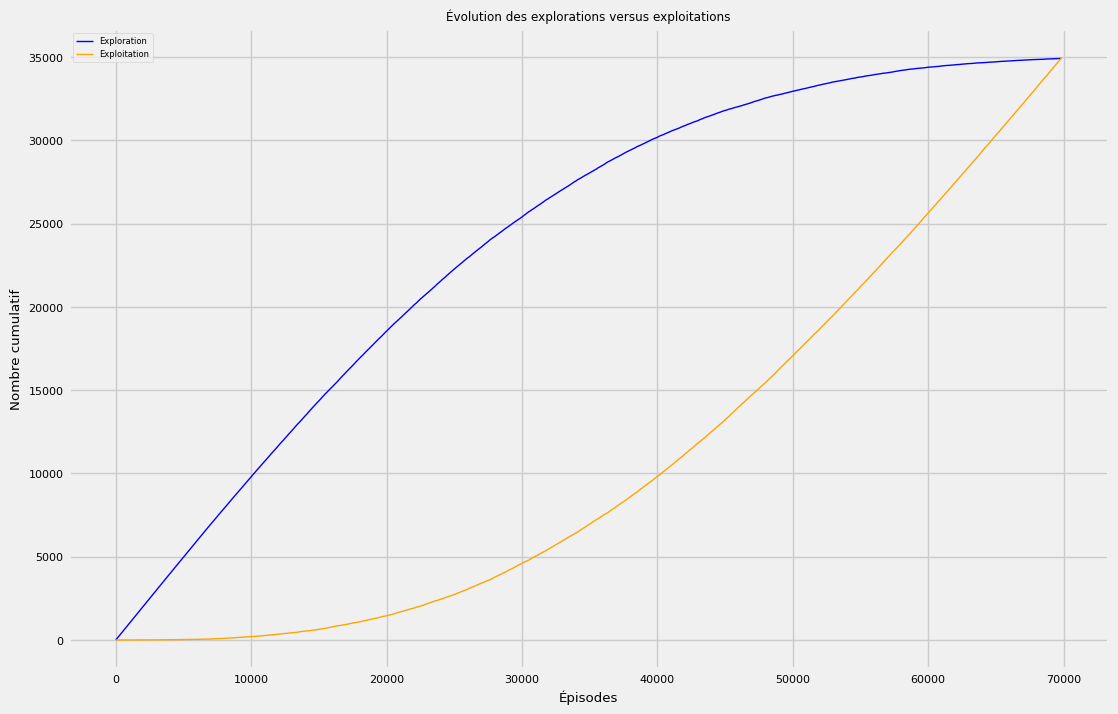

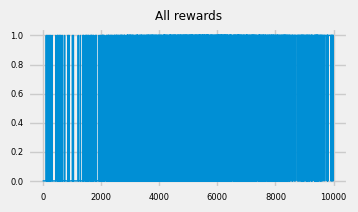

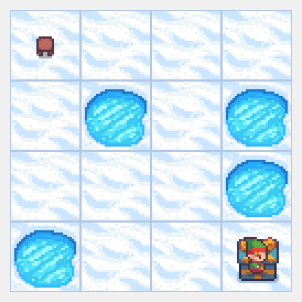

[['BAS' 'DROITE' 'BAS' 'GAUCHE']
 ['BAS' 'DROITE' 'BAS' 'HAUT']
 ['DROITE' 'DROITE' 'BAS' 'BAS']
 ['GAUCHE' 'DROITE' 'DROITE' 'HAUT']]


In [29]:
nb_actions = env.action_space.n
nb_states = env.observation_space.n

print(f"Nombre d'action : {nb_actions},  Nombre d'états : {nb_states}")

env = gym.make('FrozenLake-v1', desc=desc4, is_slippery=False,render_mode="rgb_array")
env.reset()
env.render()

Qtable = init_Qtable(nb_states,nb_actions,opts=False)
Q_table, all_rewards = train(10000, env, 1000, Qtable, gamma=0.97, alpha=0.1,  decay_rate = 0.99999993)
optimal_policy = np.argmax(Qtable, axis=1)
env.close()
# Utiliser la fonction
display_graph(all_rewards)
liste_modifiee = [action_name[element] for element in optimal_policy]

image_render()
print(np.array(liste_modifiee).reshape(int(np.sqrt(nb_states)), int(np.sqrt(nb_states))))


 - `L'algorithme e-Greedy choisi est non linéaire.`
 - `La Qtable est initialisée avec des zeros`
 - `Le mode d'exploration qui diminue au fur et à mesure de l'apprentissage au profit de l'exploitation. ` 
 - `A ce state les rewards sont non pondérés, ce qui justifient transitions de zéro à 1 des récompenses. ` 
 - `Entre zéro et 2000 épisodes de par les raies que le robot échoue et apprends dans le temps. `
 - `La politique optimale répond au problème posée à l'agent avec une initialisation de la table à zéro.`

Qtable.shape : (16, 4) : [[0.00493553 0.00657447 0.00139825 0.00011714]]


100%|██████████| 9998/9998 [00:01<00:00, 7340.37it/s]


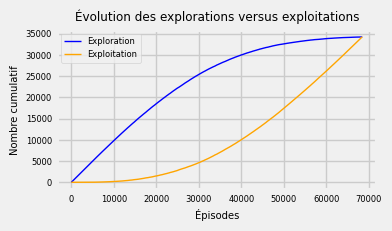

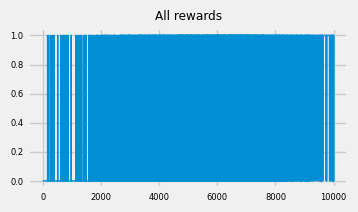

[['BAS' 'DROITE' 'BAS' 'GAUCHE']
 ['BAS' 'BAS' 'BAS' 'BAS']
 ['DROITE' 'BAS' 'BAS' 'BAS']
 ['GAUCHE' 'DROITE' 'DROITE' 'DROITE']]


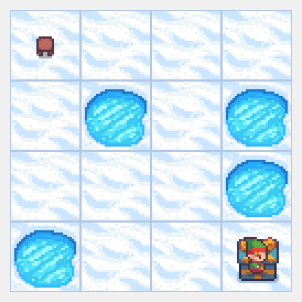

In [30]:
env = gym.make('FrozenLake-v1', desc=desc4, is_slippery=False,render_mode="rgb_array")
env.reset()
env.render()

Q_table1 = init_Qtable(nb_states,nb_actions,opts=False)
print(f'Qtable.shape : {Q_table1.shape} : {Q_table1[0:1]}')
frozen_Q, all_rewards = train(10000, env, 1000, Q_table1, gamma=0.97, alpha=0.1,  decay_rate = 0.99999993)
env.close()

optimal_policy = np.argmax(Q_table1, axis=1)
display_graph(all_rewards) 

liste_modifiee = [action_name[element] for element in optimal_policy]
print(np.array(liste_modifiee).reshape(int(np.sqrt(nb_states)), int(np.sqrt(nb_states))))
image_render()

 - `L'algorithme e-Greedy choisi est non linéaire.`
 - `La Qtable est initialisée avec des valeurs aléatoires n'est pas efficiente en 8*8`
 - `L'exploration diminue au fur et à mesure de l'apprentissage au profit de l'exploitation. ` 
 - `Les rewards sont non pondérés, ce qui justifient transitions de zéro à 1 des récompenses. ` 
 - `Entre zéro et 2000 épisodes de par les raies que le robot échoue et apprends dans le temps. `
 - `La politique optimale satisfait la solution au problème posée à l'agent.`

Dans cet environnement, la table des rewards est stockée dans un dictionnaire env.env.env.env.P .    
Observez cette table avec la fonction suivante :      
 - on voit quel état est terminal et avec quelle récompense
    - changer la récompense pour les trous
    - changer aussi récompense de faire un pas

In [31]:
env.reset()
env = gym.make('FrozenLake-v1', desc=desc, is_slippery=True,render_mode="rgb_array")

P = env.env.env.env.P
new_P = change_rewards(P, move_penalty=-5, hole_penalty=-35, goal_reward=275, flag=False)
Q_table2 = init_Qtable(env.observation_space.n,env.action_space.n,opts=True)
Q_table3, all_rewards = train(10000, env, 1000, Q_table2, gamma=0.97, alpha=0.3,  decay_rate = 0.99999991)
env.close()

optimal_policy = np.argmax(Q_table1, axis=1)
display_graph(all_rewards) 

liste_modifiee = [action_name[element] for element in optimal_policy]
print(np.array(liste_modifiee).reshape(int(np.sqrt(nb_states)), int(np.sqrt(nb_states))))
image_render()

NameError: name 'desc' is not defined

 - `L'algorithme e-Greedy choisi est non linéaire.`
 - `La Qtable est initialisée avec des valeurs aléatoires`
 - `Le mode d'exploration qui diminue au fur et à mesure de l'apprentissage au profit de l'exploitation. ` 
 - `A ce state les rewards sont non pondérés, ce qui justifient transitions de zéro à 1 des récompenses. ` 
 - `Entre zéro et 2000 épisodes de par les raies que le robot échoue et apprends dans le temps. `
 - `La politique optimale répond au problème posée à l'agent avec une initialisation de la table à zéro.`

`Premier graphique`

 - Les récompenses oscillent principalement entre 10 et -20
 - On observe des pics positifs fréquents jusqu'à +10, indiquant que l'agent atteint régulièrement l'objectif
 - Les creux négatifs sont moins profonds, suggérant que l'agent apprend à éviter les situations les plus pénalisantes
 - La variation importante des récompenses indique que l'agent alterne entre succès et échecs

`Ajustement de l'exploration (epsilon)`     

 Améliorer l'apprentissage avec l'algorithme epsilon-greedy, plusieurs paramètres peuvent être ajustés se basant sur les graphiques de récompenses 

 - Commençons avec un epsilon plus élevé (par exemple 0.8) pour favoriser l'exploration initiale
 - Implémentons une décroissance progressive de epsilon (decay) au fil des épisodes.
    - epsilon = max(0.01, epsilon * decay_rate)  # decay_rate autour de 0.995

`Optimisation des hyperparamètres`

 - Augmenter le taux d'apprentissage (alpha) au début (0.2-0.3) puis le réduire progressivement
 - Ajuster le facteur d'actualisation gamma (0.98-0.99) pour donner plus d'importance aux récompenses futures
 - Augmenter le nombre d'épisodes d'entraînement (>10000) pour permettre une meilleure convergence

`Modification des récompenses`

 - Augmenter le contraste entre récompenses positives et négatives
 - Réduire légèrement la pénalité de mouvement (-0.1 au lieu de -1)
 - Maintenir une forte récompense pour l'objectif (+10)
 - Garder une pénalité significative pour les trous (-5)

Ces ajustements devraient permettre d'obtenir un graphique plus stable avec des pics positifs plus fréquents et des creux moins profonds, indiquant un meilleur apprentissage.    

Ensuite :
   - Faire une fonction qui évalue les performances de l'agent à partir de la table de Q
   - Esayer d'améliorer l'apprentissage en jouant sur les différents paramètres
   - Une option possible pour l'exploration est de faire un epsilon variable, qui diminue au fur et à mesure qu'on connait mieux l'environnement
   - Ecrire une fonction qui simule un épisode avec la table Q finale puis visualisez avec play_video
   - Appliquez le tout aussi à l'environnement "slippery" (glissant) où les actions sont non-déterministes
   - Essayez avec un environnement plus grand 8x8 et/ou une grille définie par vous-même.

In [ ]:
def evaluate_agent(env, max_steps, n_episodes, Qtable):
    # doit renvoyer la moyenne et l'écart-type du total des récompenses par épisode
    all_rew = []
    for episode in tqdm(range(n_episodes)):
        state, _ = env.reset()
        total_reward = 0
        for step in range(max_steps):
            # Sélectionner la meilleure action (politique gloutonne)
            action = np.argmax(Qtable[state,:])
            # Faire l'action
            next_state, reward, done, truncated, _ = env.step(action)
            total_reward += reward
            env.render()
            if done or truncated:
                break
            state = next_state
        all_rew.append(total_reward)        
  
    stats = np.array(all_rew)
    std_reward  =  np.std(all_rew)
    mean_reward =  np.mean(all_rew)
    return mean_reward, std_reward

In [ ]:
# Tester l'agent sur FrozenLake avec is_slippery=True
test_env = gym.make("FrozenLake-v1",  desc=desc, is_slippery=True, render_mode="rgb_array")
env.render()
Q_table = init_Qtable(nb_states,nb_actions,opts=True)
new_P = change_rewards(P, move_penalty=-5, hole_penalty=-35, goal_reward=275, flag=False)
Q_table, all_rewards = train(10000, test_env, 500, Q_table, gamma=0.97, alpha=0.05, decay_rate = 0.99999997)
mean_reward ,std_reward = evaluate_agent(test_env,10000,500,Q_table)
display_graph(all_rewards) 
env.close()
print(f'ecart-type : {std_reward} espérance {mean_reward}')

In [ ]:
def simulation(env, Qtable, max_steps=100):
    state, _ = env.reset()
    for step in range(max_steps):     
        action = np.argmax(Qtable[state])    
        state, reward, done, truncated, info = env.step(action)   
        if done or truncated:
            break
    return env.render()


In [ ]:
import os

steps = 1000

env = gym.make("FrozenLake-v1", desc=desc, is_slippery=True, render_mode="rgb_array")
env = RecordVideo(env, video_folder="FrozenLake", name_prefix="eval", episode_trigger=lambda x: True)
env = RecordEpisodeStatistics(env, buffer_length=steps)
images = simulation(env, Q_table, max_steps=steps)
env.close()

In [ ]:
# 4. Lire la vidéo
play_video("FrozenLake/eval-episode-0.mp4",width=600)

`Le système fonctionne en mode is_sliperry=True`